In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="pWuLEylirXXr6FysjezZ")
project = rf.workspace("omar-husnye").project("new-fruits-wgdh2")
version = project.version(3)
dataset = version.download("yolov8")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 7.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 36.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 67.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 101.9 MB/s eta 0:00:0000:01
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to New-Fruits-3 in yolov8:: 100%|██████████| 20605/20605 [00:02<00:00, 9410.23it/s] 


In [3]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 25.6 MB/s eta 0:00:00a 0:00:01


In [4]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
!yolo task=detect mode=train model=yolov8s.pt data={dataset.location}/data.yaml epochs=30 imgsz=640 plots=True patience=10 batch=16

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/New-Fruits-3/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimi

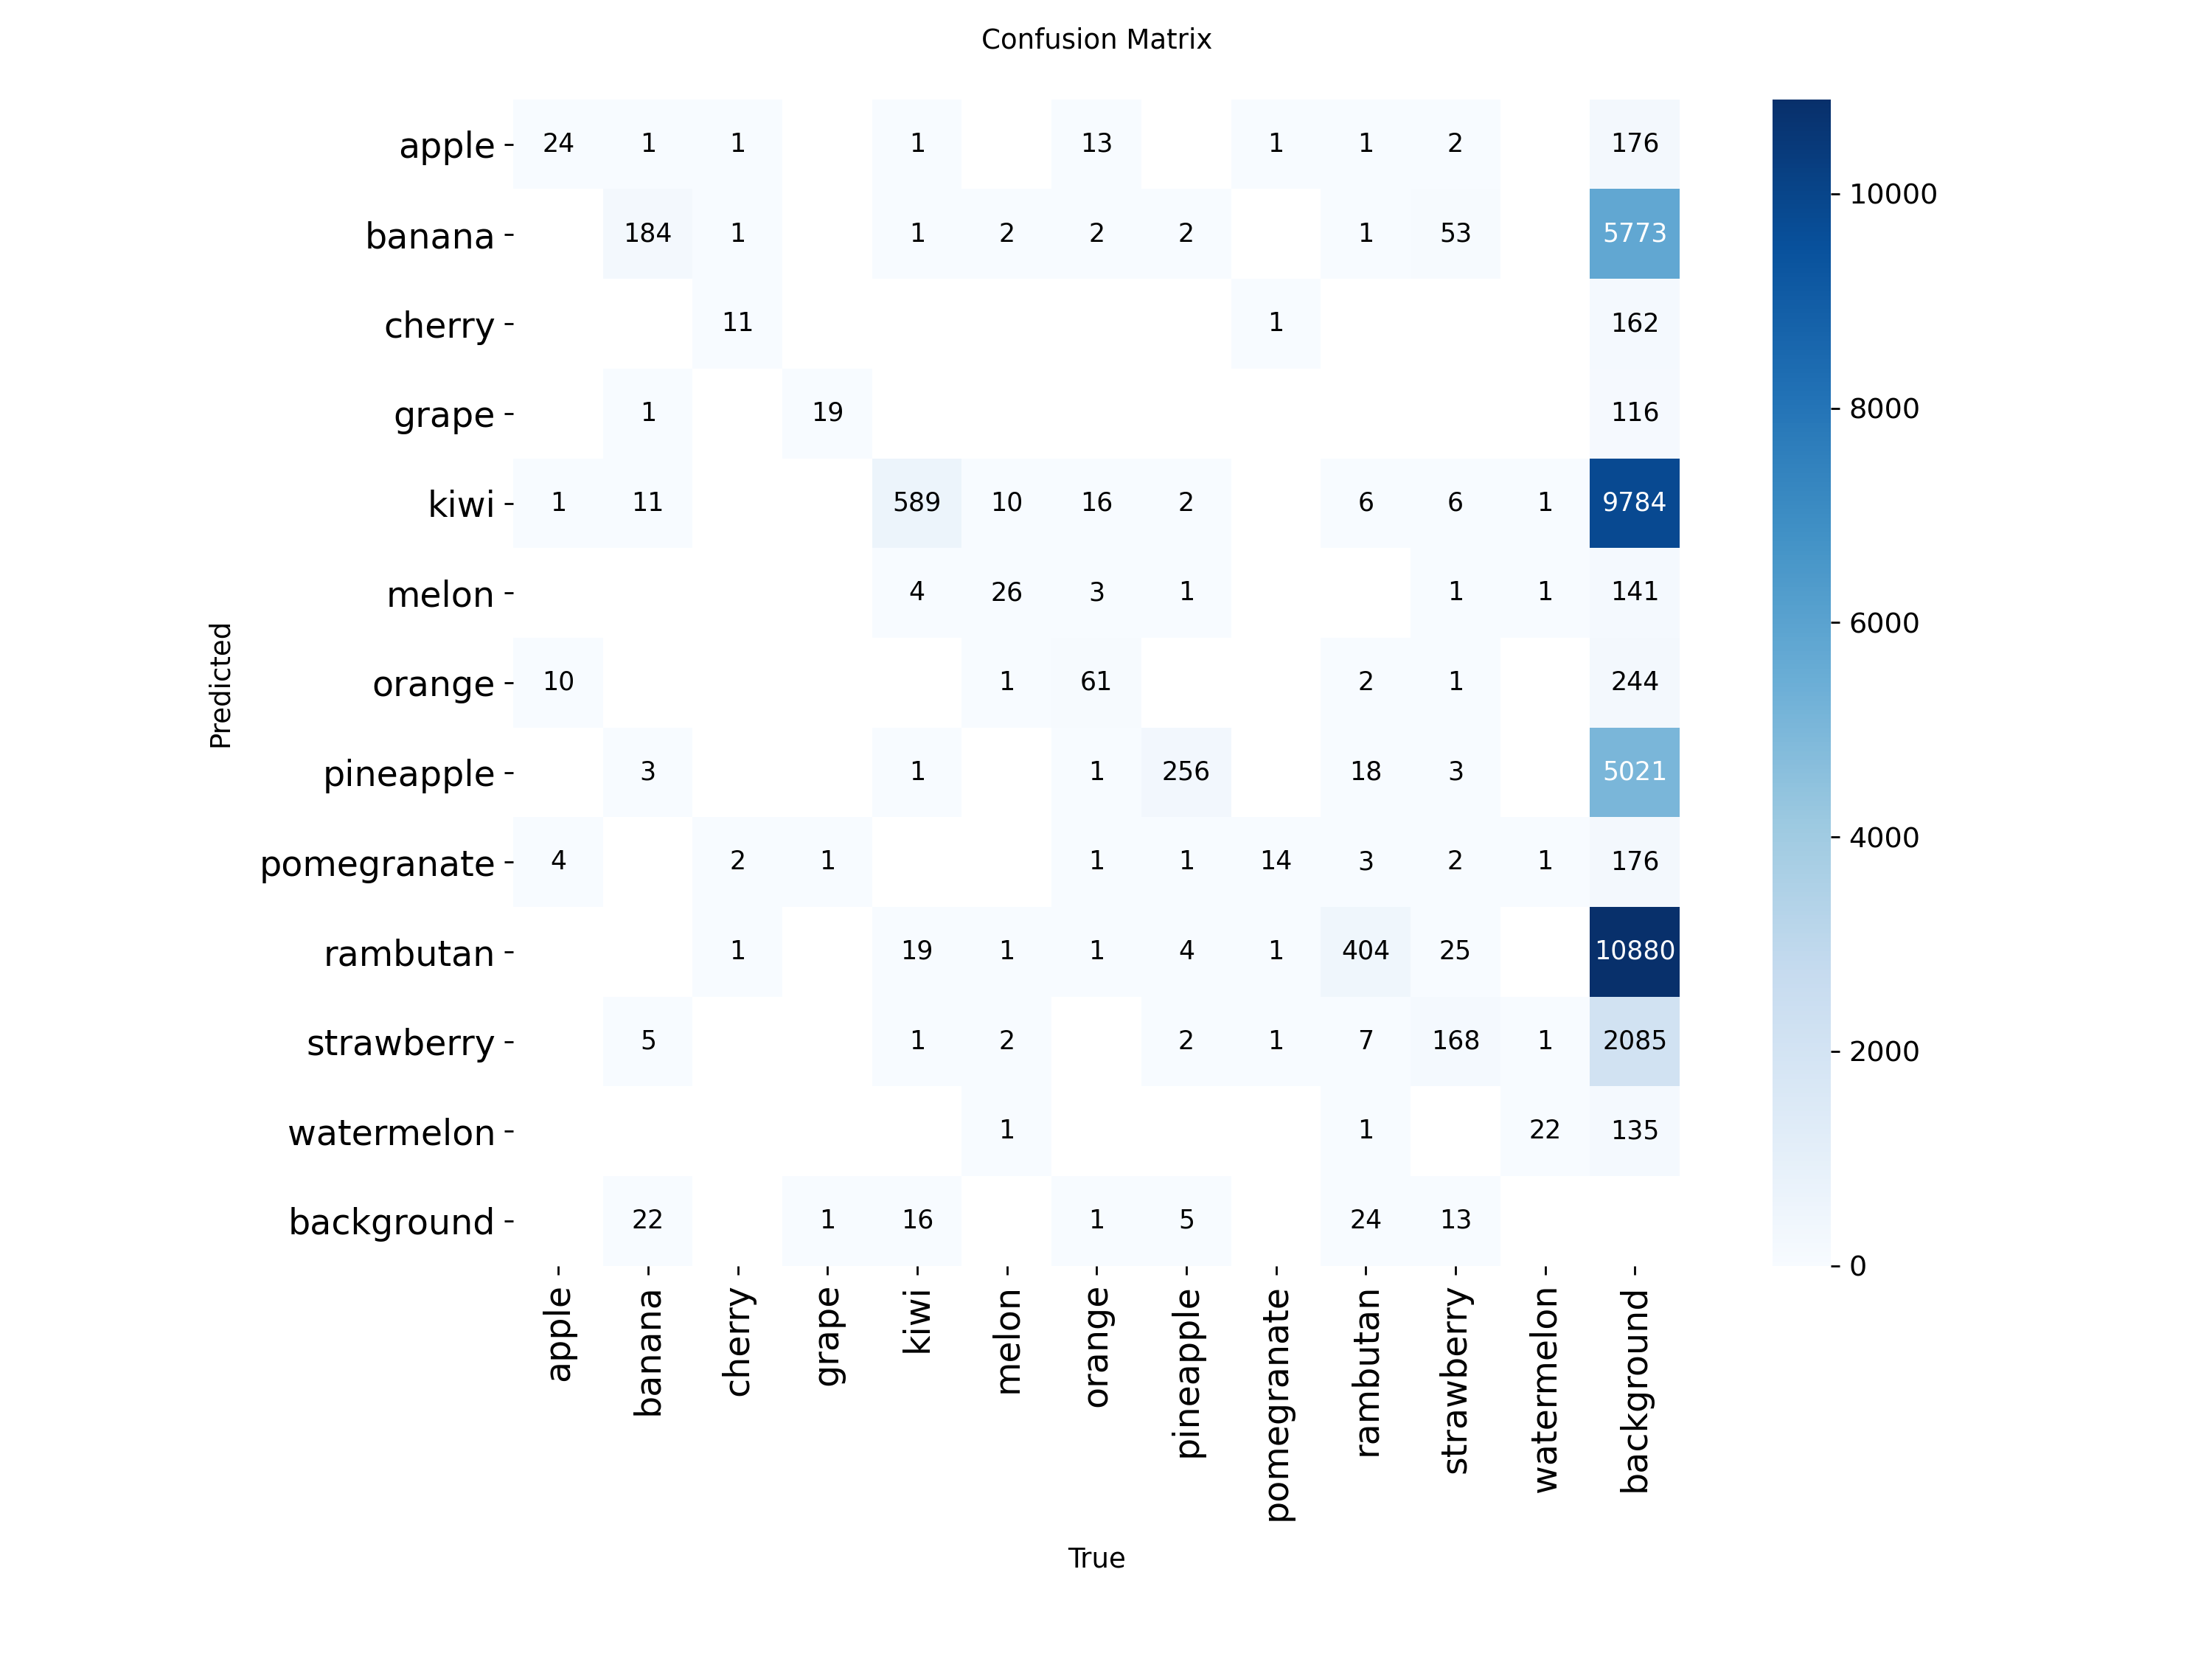

In [6]:
from IPython.display import Image
Image(filename="/kaggle/working/runs/detect/train/confusion_matrix.png", width=600)

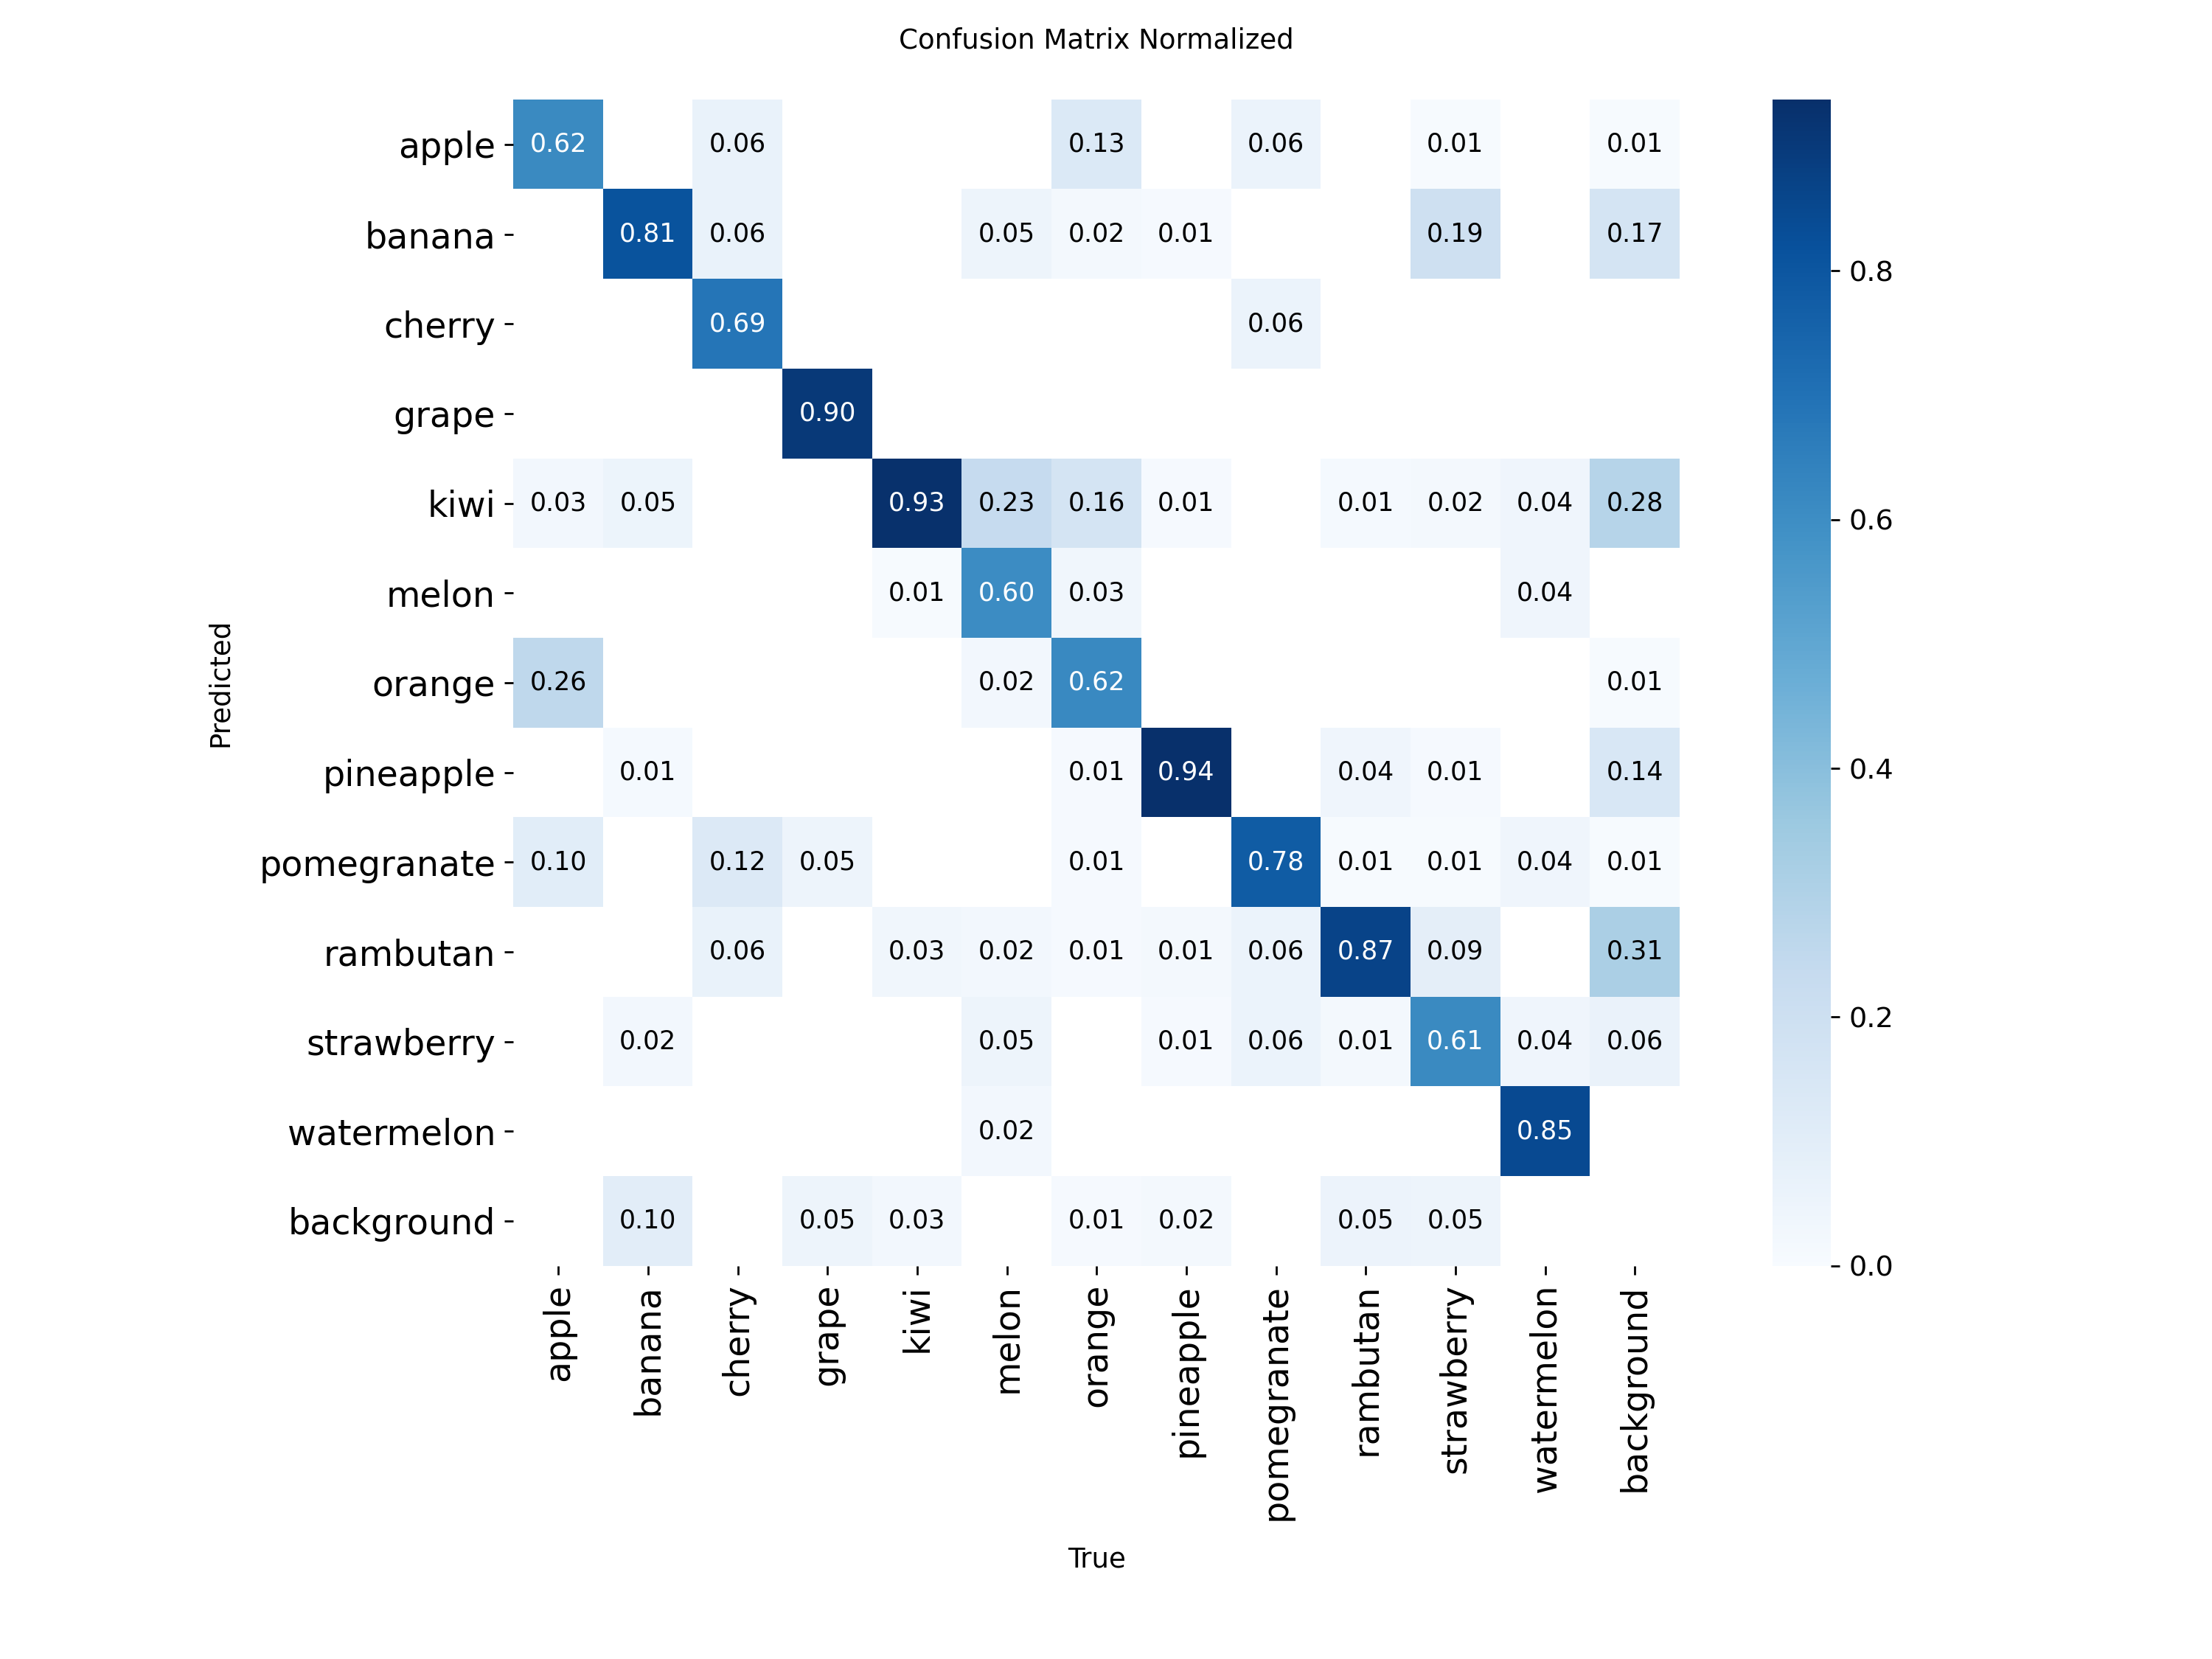

In [7]:
Image(filename="/kaggle/working/runs/detect/train/confusion_matrix_normalized.png", width=600)

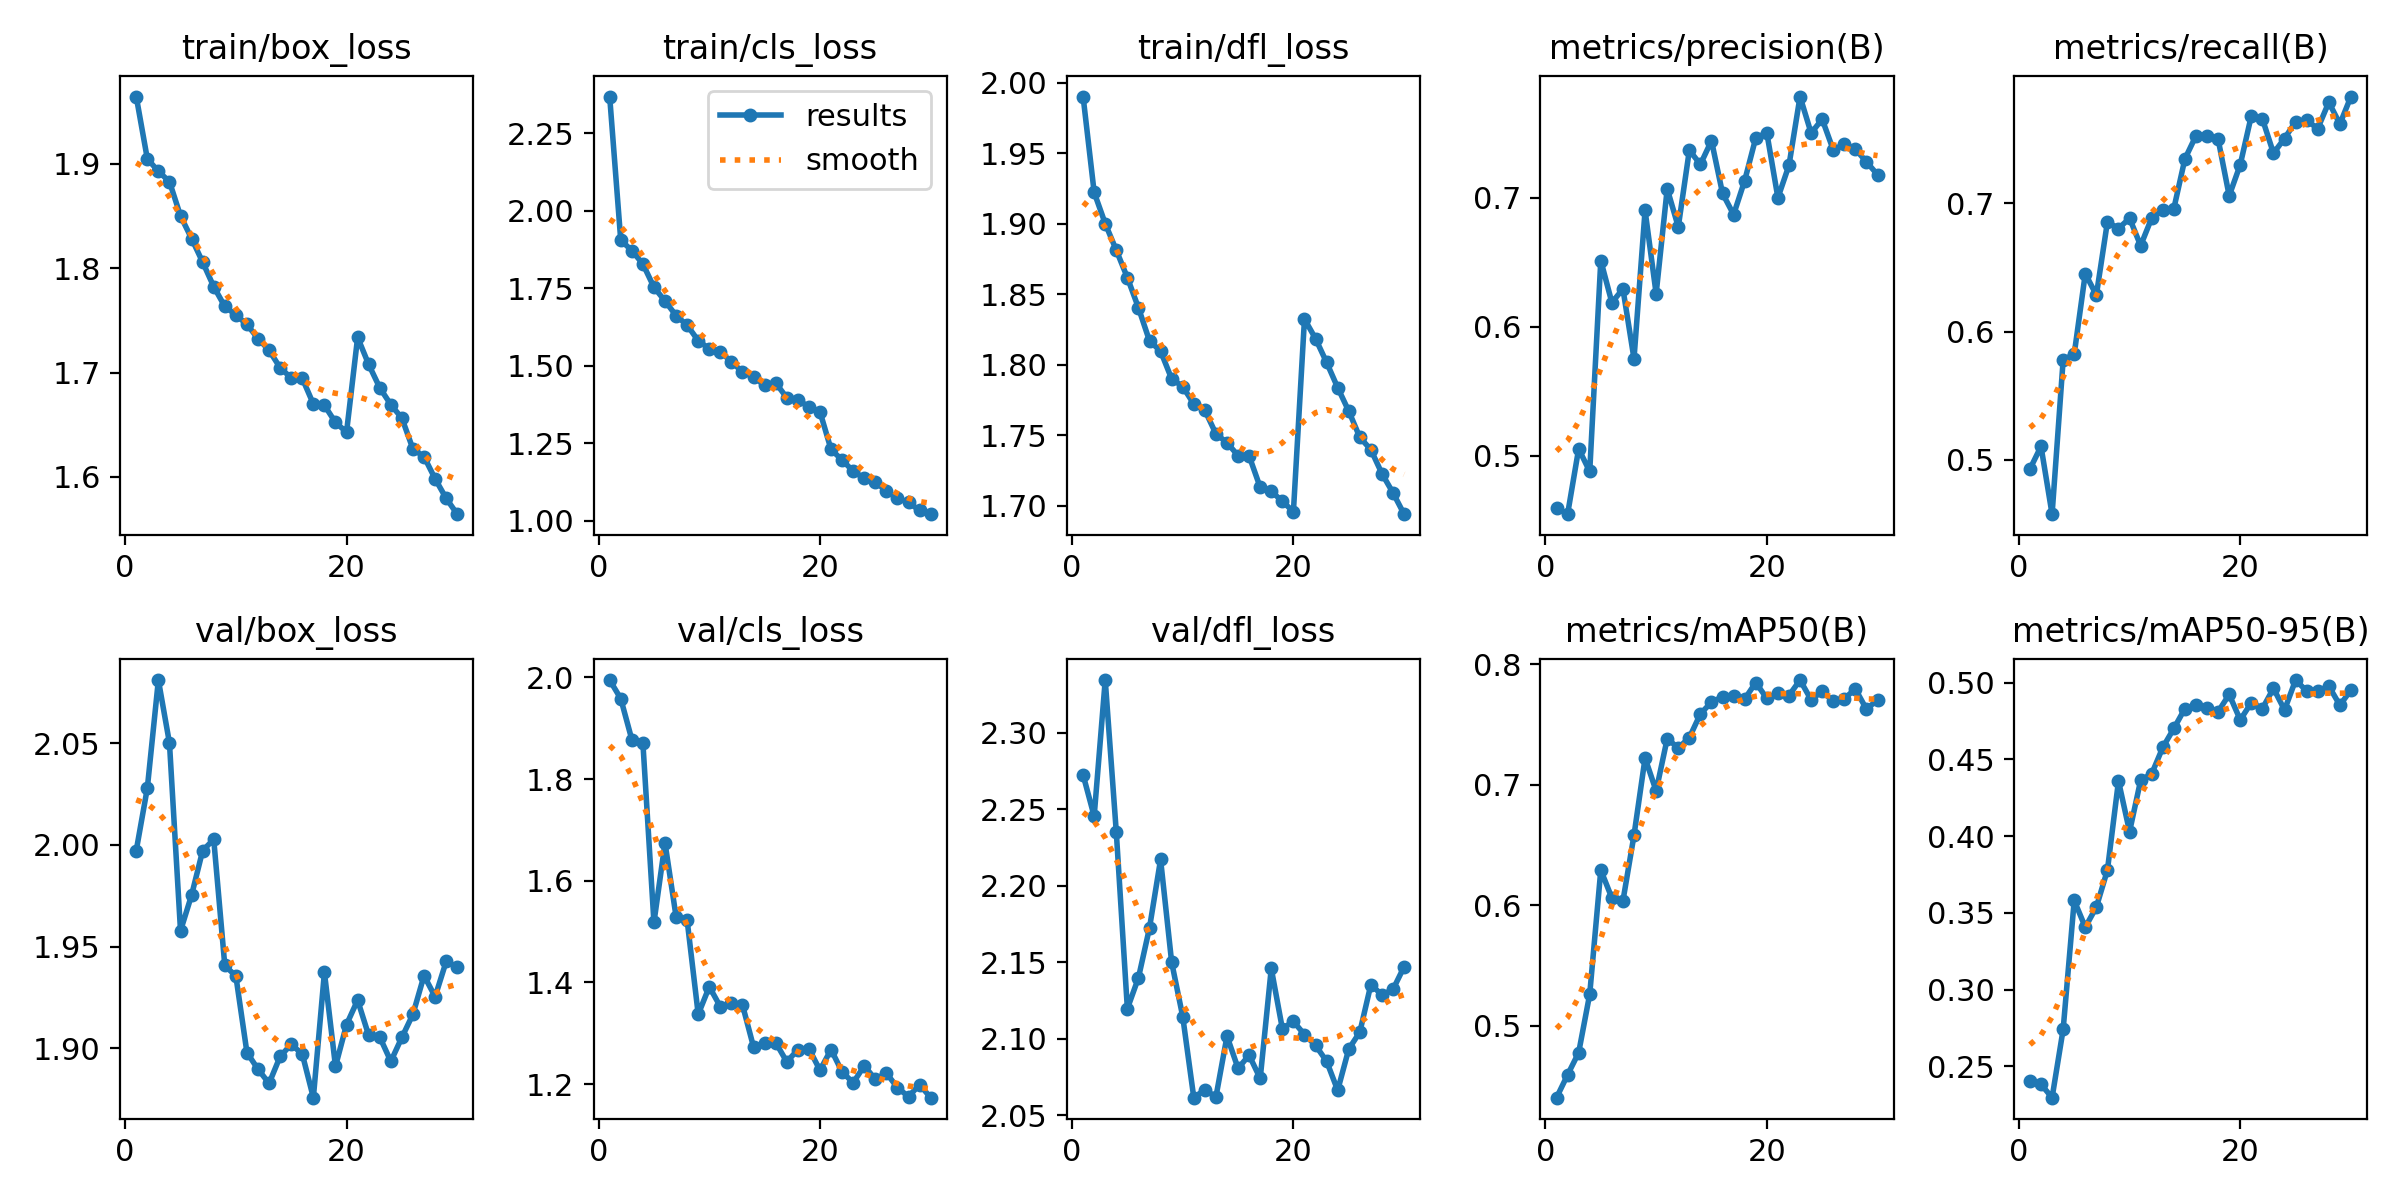

In [8]:
Image(filename="/kaggle/working/runs/detect/train/results.png", width=600)

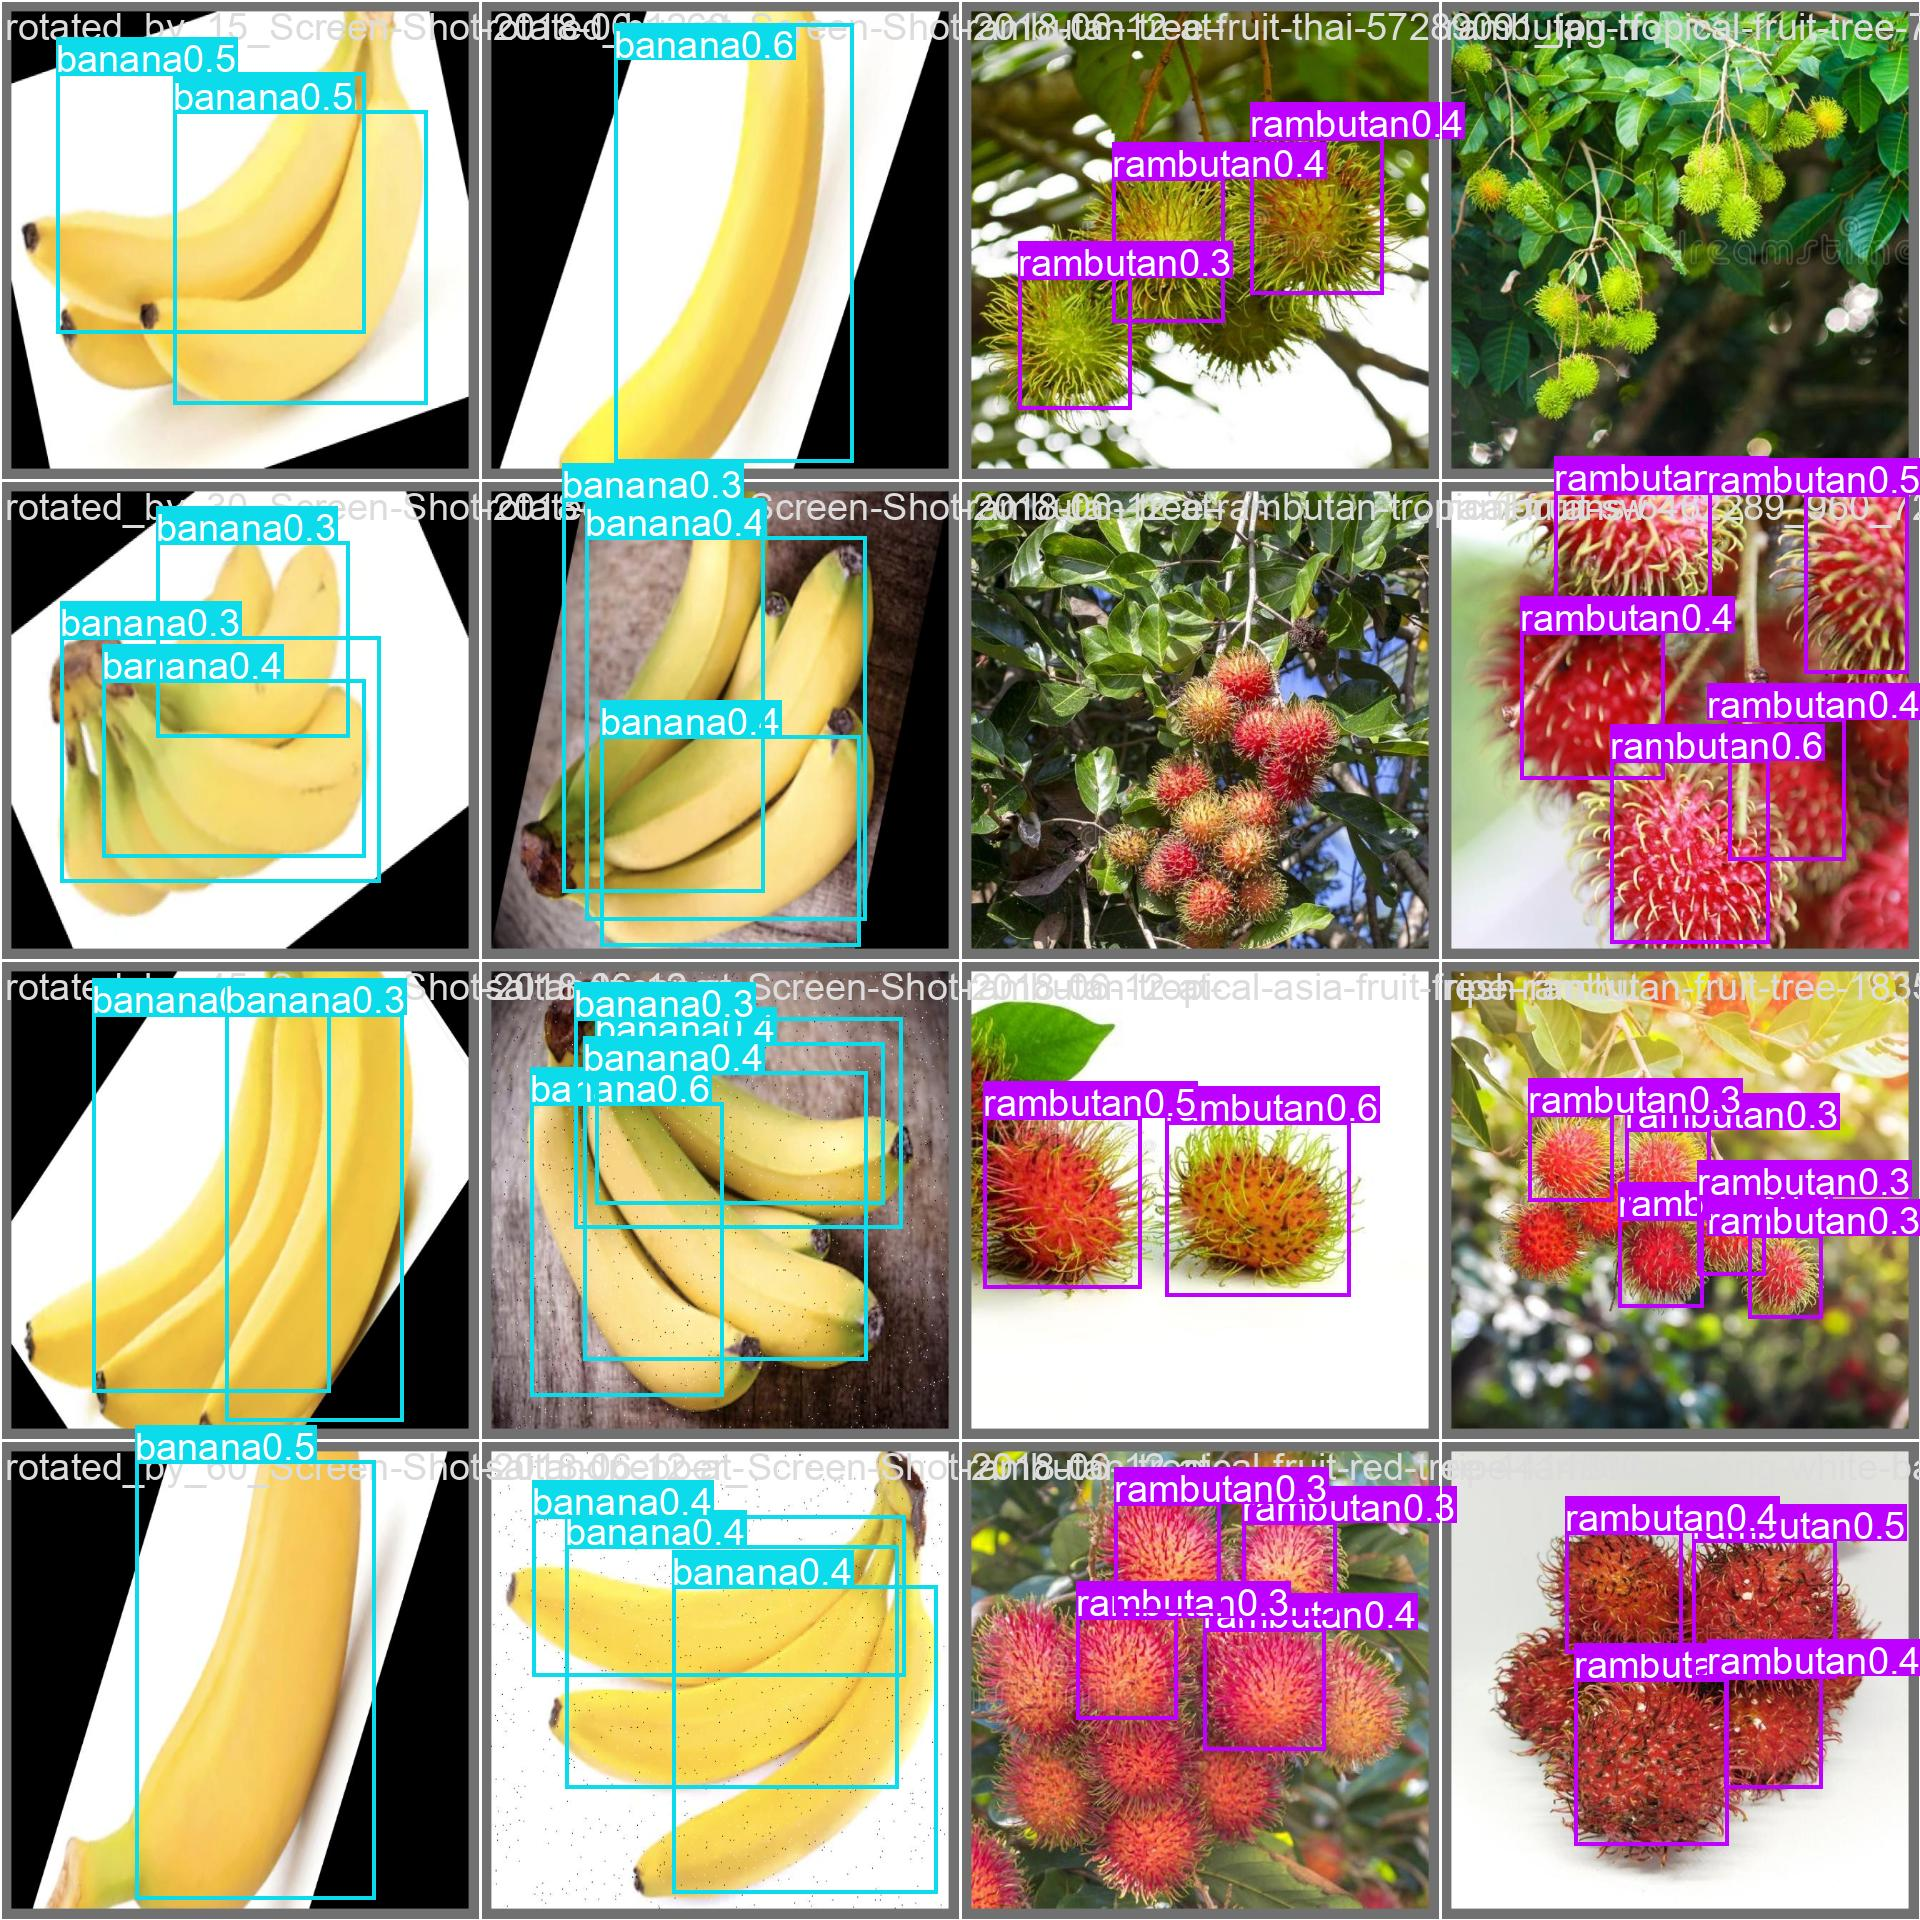

In [9]:
Image(filename="/kaggle/working/runs/detect/train/val_batch0_pred.jpg", width=600)

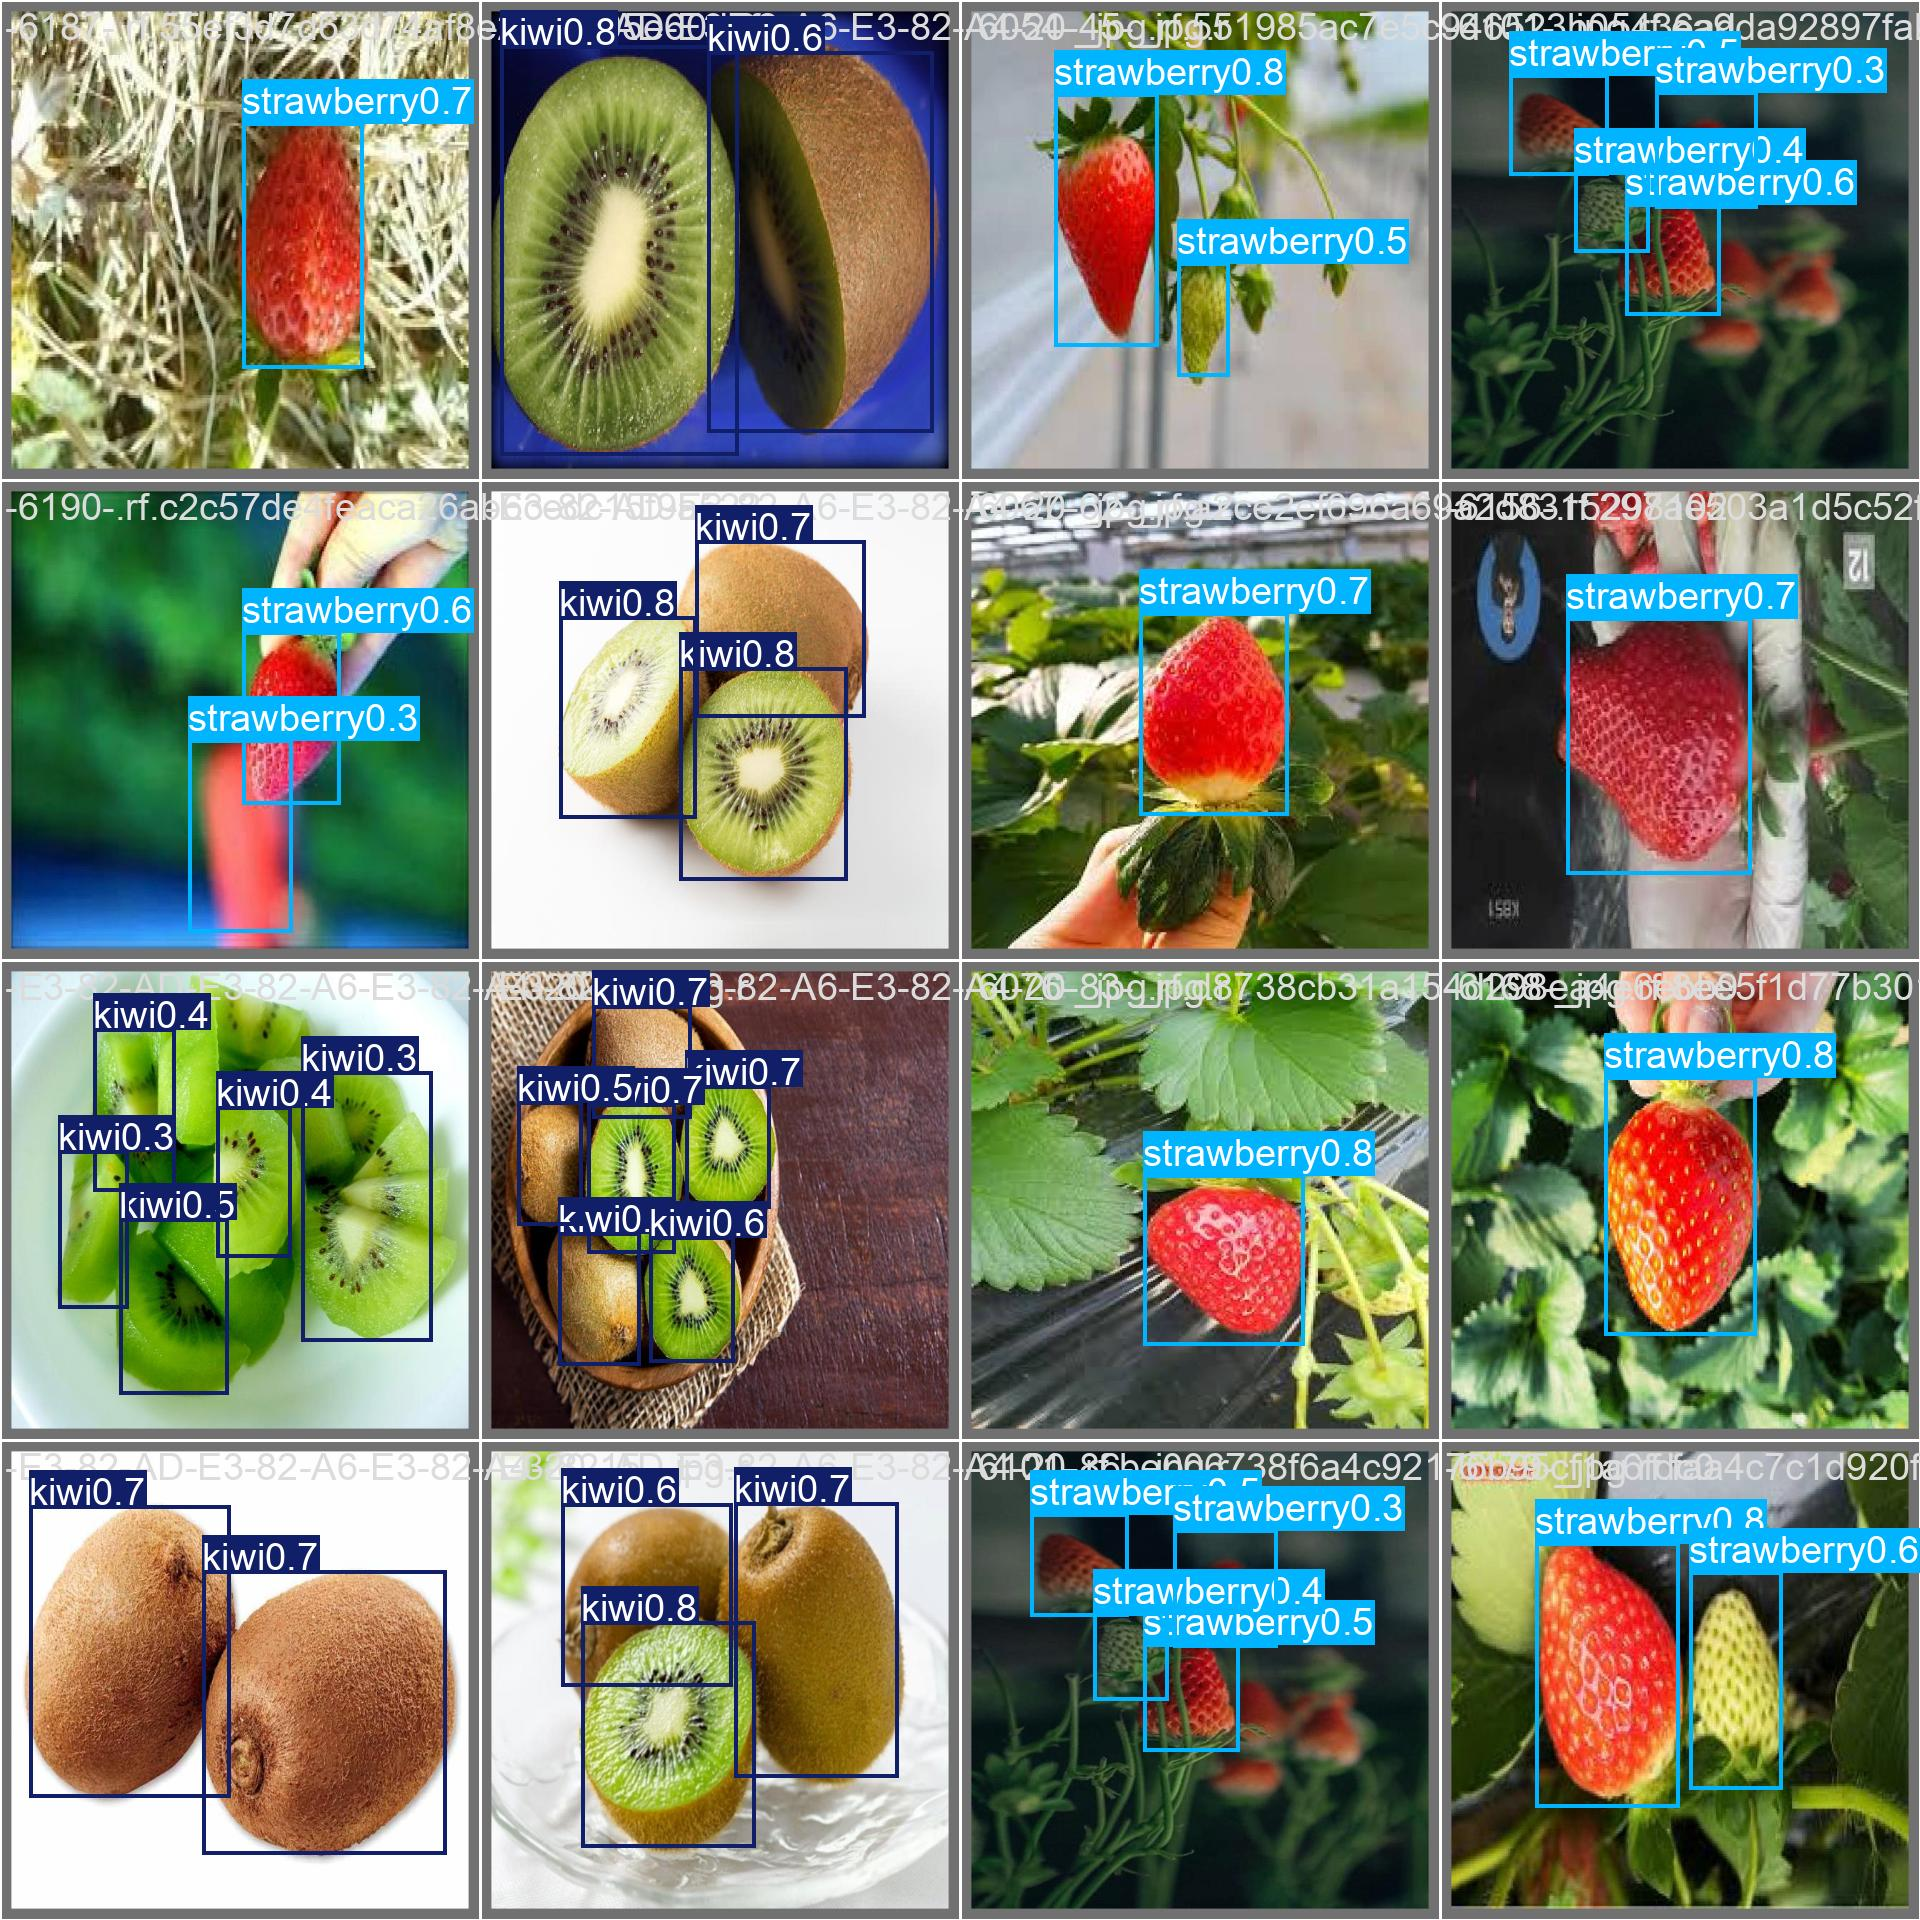

In [10]:
Image(filename="/kaggle/working/runs/detect/train/val_batch1_pred.jpg", width=600)

In [12]:
!yolo task=detect mode=val model=/kaggle/working/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 73 layers, 11,130,228 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1404.7±528.3 MB/s, size: 45.1 KB)
val: Scanning /kaggle/working/New-Fruits-3/valid/labels.cache... 909 images, 84 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 909/909 158.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 57/57 4.5it/s 12.7s0.2s
                   all        909       2135      0.765      0.761      0.777      0.501
                 apple         16         39      0.777          1      0.952      0.839
                banana        128        227      0.551      0.535      0.486      0.198
                cherry         10         16      0.545       0.75      0.673      0.528
                 grape         11         21      0.803      0.714      0.817      0.469
                  kiwi     

In [13]:
!yolo task=detect mode=predict model=/kaggle/working/runs/detect/train/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 73 layers, 11,130,228 parameters, 0 gradients, 28.5 GFLOPs

image 1/909 /kaggle/working/New-Fruits-3/test/images/-135-_jpg.rf.6454b3d8cc2aae59d2c3ce9f07edea11.jpg: 640x640 1 strawberry, 16.2ms
image 2/909 /kaggle/working/New-Fruits-3/test/images/-138-_jpg.rf.1bc64a06f8e313bd9fcc2d0bccf0e084.jpg: 640x640 1 strawberry, 16.2ms
image 3/909 /kaggle/working/New-Fruits-3/test/images/-153-_jpg.rf.783460d86b213e341cf281bd17afe962.jpg: 640x640 1 strawberry, 16.2ms
image 4/909 /kaggle/working/New-Fruits-3/test/images/-158-_jpg.rf.ec26d48a933a1b514321af887bd09afb.jpg: 640x640 1 strawberry, 16.2ms
image 5/909 /kaggle/working/New-Fruits-3/test/images/-183-_jpg.rf.73afb8863a821e835dc154ebbd4a8f5e.jpg: 640x640 1 strawberry, 16.1ms
image 6/909 /kaggle/working/New-Fruits-3/test/images/-195-_jpg.rf.3d614dc2b93775324a645be10d2a96f6.jpg: 640x640 1 strawberry, 16.1ms
image 7/909 /kaggle/working/New-Fru

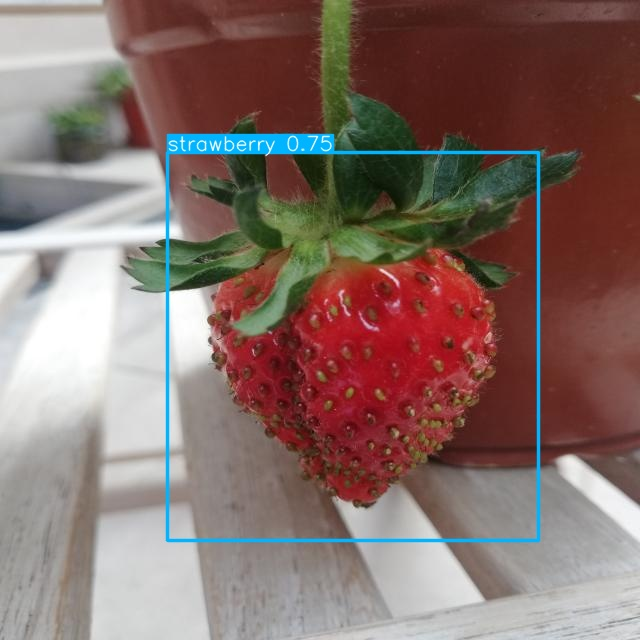

In [14]:
Image(filename="/kaggle/working/runs/detect/predict/-135-_jpg.rf.6454b3d8cc2aae59d2c3ce9f07edea11.jpg", width=600)

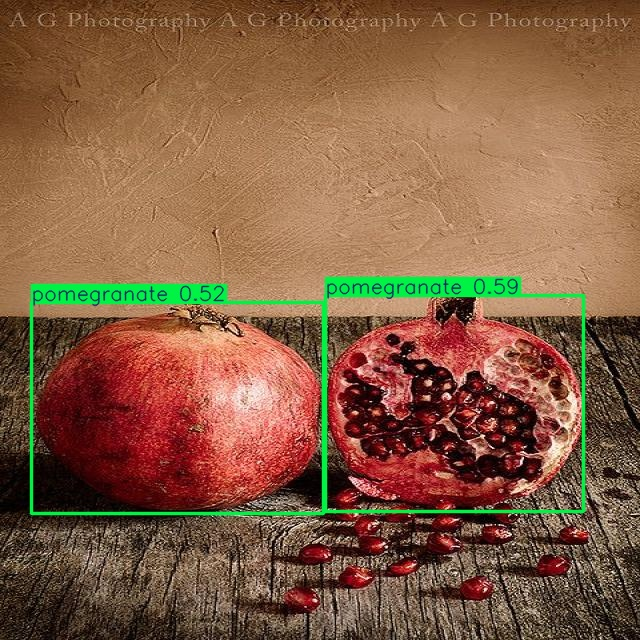

In [15]:
Image(filename="/kaggle/working/runs/detect/predict/636_jpg.rf.122b12f2db1bd02c3cbf4a85a11cbacd.jpg", width=600)

In [16]:
project.version(dataset.version).deploy(model_type='yolov8', model_path='/kaggle/working/runs/detect/train')

ultralytics==8.0.196 is recommended for this upload, but ultralytics 8.4.104 is installed. Retry with allow_dependency_mismatch=True to package with the installed version, or `pip install ultralytics==8.0.196`.


Would you like to continue anyway? y/n:  y


ultralytics==8.0.196 is recommended for this upload, but ultralytics 8.4.104 is installed.
Inferred model size 'yolov8s' from the checkpoint architecture (model_type was 'yolov8').
View the status of your deployment at: https://app.roboflow.com/omar-husnye/new-fruits-wgdh2/3
Share your model with the world at: https://universe.roboflow.com/omar-husnye/new-fruits-wgdh2/model/3


In [17]:
from IPython.display import FileLink

# Generate download link for best.pt
FileLink(r'runs/detect/train/weights/best.pt')

/kaggle/working/runs/detect/train/weights/best.pt